# ROTATE on a single neuron

<a href="https://colab.research.google.com/github/AsafAvr/rotating-neurons/blob/main/notebooks/rotate_one_neuron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A minimal, self-contained walk-through of **ROTATE** from
[*Disentangling MLP Neuron Weights in Vocabulary Space*](https://arxiv.org/abs/2604.06005)
(Avrahamy, Gur-Arieh, Geva, 2026).

An MLP neuron's weight vector `w` lives in the residual stream, so we can read it in vocabulary space
by projecting it onto the unembedding matrix: `w @ W_U` gives one score per token. For most neurons
this projection is a blur of several unrelated concepts. ROTATE splits the neuron into
**vocabulary channels**: directions close to `w` whose vocabulary projection is *sparse*, meaning
a few tokens stand far out from the rest. It needs **no data and no forward passes**, only `w` and `W_U`.

We will:

1. look at one neuron in vocabulary space,
2. find one channel by hand in ~20 lines (the whole idea of the method),
3. run the full method, which finds several channels by masking and repeating,
4. compare the channels with the neuron.

**Runtime:** a free Colab **T4 GPU** is enough (*Runtime → Change runtime type → T4 GPU*). Only the
neuron's weights and the unembedding matrix are downloaded (~1.2 GB for Gemma, ~1 GB for Llama),
never the full model.


## 0. Setup

Gemma and Llama are **gated** on Hugging Face. Once, accept the licence on the model page
([Gemma-2-2B-it](https://huggingface.co/google/gemma-2-2b-it),
[Llama-3.1-8B-Instruct](https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct)), then create a
[read token](https://huggingface.co/settings/tokens). In Colab, store it as a secret named `HF_TOKEN`
(key icon in the left sidebar) so it never appears in the notebook; otherwise you will be asked to paste it.


In [5]:
import sys

if "google.colab" in sys.modules:
    !pip install -q git+https://github.com/AsafAvr/rotating-neurons

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [6]:
import torch

MODEL = "gemma"  # "gemma" (Gemma-2-2B-it) or "llama" (Llama-3.1-8B-Instruct)

EXAMPLES = {  # (layer, neuron, which weight vector of the neuron)
    "gemma": dict(layer=18, neuron=9005, mlp_type="gate"),  # the paper's running example
    "llama": dict(layer=20, neuron=10675, mlp_type="gate"),
}
LAYER, NEURON, MLP_TYPE = EXAMPLES[MODEL]["layer"], EXAMPLES[MODEL]["neuron"], EXAMPLES[MODEL]["mlp_type"]

NUM_CHANNELS = 5     # the paper uses 50; the first few are the strongest
MAX_STEPS = 10_000   # paper setting (runs stop early once the loss plateaus); lower it for a quicker look
SOURCE = None        # None: the official HF repo. Or a local directory with the safetensors checkpoint.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{MODEL} | layer {LAYER} | neuron {NEURON} ({MLP_TYPE}) | device: {DEVICE}")

gemma | layer 18 | neuron 9005 (gate) | device: cuda


In [14]:
from huggingface_hub import get_token, login

if SOURCE is None and get_token() is None:  # in Colab, get_token() also reads the HF_TOKEN secret
    login()

## 1. Load one neuron and the vocabulary projection

A gated MLP neuron has three weight vectors in the residual space: `w_gate` and `w_in` (what the
neuron *reads*) and `w_out` (what it *writes*). Any of them can be decomposed; the paper's example
uses `w_gate`.

`U` is the matrix that maps a residual-space vector to token scores: the unembedding `W_U`
(for early Llama layers, `<= 12`, the input embedding `W_E.T`, which those neurons align with better).
Both are read straight from the checkpoint's safetensors files; the model is never loaded.


In [15]:
import time

from rotate.models import (
    MODEL_CONFIGS, default_token_weights, get_neuron, load_tokenizer, projection_matrix, uses_embedding_matrix,
)

t0 = time.time()
tokenizer = load_tokenizer(MODEL, SOURCE)
U = projection_matrix(MODEL, LAYER, device=DEVICE, source=SOURCE)          # (d_model, vocab)
w = get_neuron(MODEL, LAYER, NEURON, MLP_TYPE, source=SOURCE).to(DEVICE)   # (d_model,)
m = default_token_weights(MODEL, U).to(DEVICE)                             # (vocab,) token weights, see below

print(f"U = {'W_E.T' if uses_embedding_matrix(MODEL, LAYER) else 'W_U'} {tuple(U.shape)}, w {tuple(w.shape)}, "
      f"loaded in {time.time() - t0:.0f}s")
print(f"tokens ignored by the objective (weight 0): {int((m == 0).sum())}, down-weighted: {int((m == 1e-4).sum())}")

U = W_U (2304, 256000), w (2304,), loaded in 6s
tokens ignored by the objective (weight 0): 2735, down-weighted: 2560


`m` holds per-token weights used inside the objective. For Gemma, ~5k special, unused and rare
tokens get weight 0 because their embeddings are outliers that would dominate any projection. For both
models, the 1% of tokens with the largest columns in `U` are down-weighted to `1e-4`.

## 2. The neuron in vocabulary space

The **excess kurtosis** of a projection measures how heavy its tails are: 0 for a Gaussian, large when a
few tokens stand far out from the rest. A neuron that encodes one coherent concept has high kurtosis;
a neuron mixing several concepts usually does not, and its extreme tokens look unrelated.


In [16]:
from rotate import kurtosis, skewness


def zscores(vec):
    logits = vec.float() @ U
    return (logits - logits.mean()) / logits.std()


def top_tokens(vec, k=12, tail=None):
    # Tokens at the far end of one tail of vec's vocabulary projection (default: the heavier tail).
    z = zscores(vec)
    if tail is None:
        tail = 1 if skewness(z) >= 0 else -1
    score = (tail * z).masked_fill(m == 0, float("-inf"))  # hide tokens the objective ignores
    idx = torch.topk(score, k).indices.tolist()
    return [f"{tokenizer.decode([i])!r} ({float(z[i]):+.1f})" for i in idx]


z_w = zscores(w)
print(f"neuron {NEURON}: kurtosis {float(kurtosis(z_w)):.1f}, skewness {float(skewness(z_w)):+.2f}\n")
print("top tokens (+):", ", ".join(top_tokens(w, tail=+1)))
print("\ntop tokens (-):", ", ".join(top_tokens(w, tail=-1)))

neuron 9005: kurtosis 0.3, skewness +0.15

top tokens (+): ' propOrder' (+8.3), 'Until' (+6.6), 'until' (+6.6), 'GEBURTSDATUM' (+6.4), ' Until' (+6.3), ' until' (+6.2), ' Delayed' (+6.1), '直到' (+6.1), ' UNTIL' (+6.0), 'NameInMap' (+6.0), ' dopiero' (+6.0), 'HtmlAttribute' (+5.8)

top tokens (-): ' not' (-5.5), ' short' (-4.9), ' please' (-4.8), ' μην' (-4.7), 'not' (-4.5), ' passing' (-4.4), ' over' (-4.2), ' already' (-4.2), ' mark' (-4.1), ' too' (-4.1), ' disambiguazione' (-4.0), 'over' (-3.9)


## 3. One channel, by hand

ROTATE looks for a direction `c` that is

* **sparse in vocabulary space**: high kurtosis of `c @ U`, and
* **still part of the neuron**: high cosine similarity to `w`.

The direction is parametrised as a **Householder reflection** of the neuron itself,
`c = H(u) w = w - 2 u (u·w) / |u|²`. A reflection is an orthogonal map, so `c` always has the norm of `w`,
and we can optimise the free vector `u` with plain gradient descent. The loss is

```
loss(u) = -0.3 * signed_log(kurtosis((H(u) w) @ U * m)) + 1.0 * (1 - cos(w, H(u) w))
```

where `signed_log(x) = sign(x) log(1 + |x|)` keeps the gradient scale similar across neurons. Every 100
steps the current `c` is scored by the kurtosis of its *unweighted* projection, and the best one is kept.
The library version below adds learning-rate warm-up, mixed precision, early stopping and batching over neurons.


In [17]:
torch.manual_seed(0)


def reflect(u, w):  # H(u) w: orthogonal, so |H(u) w| = |w|
    return w - 2 * u * (u @ w) / (u @ u)


def signed_log(x):
    return torch.sign(x) * torch.log1p(x.abs())


u = torch.randn_like(w).requires_grad_()  # the only parameter
opt = torch.optim.AdamW([u], lr=8e-4, weight_decay=0.01)
history, best_kurt, best_c = [], 0.0, w.clone()

for step in range(min(MAX_STEPS, 3000)):
    c = reflect(u, w)
    loss = -0.3 * signed_log(kurtosis(c @ U * m)) + 1.0 * (1 - torch.cosine_similarity(c, w, dim=0))
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step % 100 == 0:
        with torch.no_grad():
            k = float(kurtosis(c @ U))
            history.append((step, k, float(torch.cosine_similarity(c, w, dim=0))))
            if abs(k) > abs(best_kurt):
                best_kurt, best_c = k, c.detach().clone()

print(f"kurtosis: neuron {float(kurtosis(w @ U)):.1f} -> channel {best_kurt:.1f}, "
      f"cos(neuron, channel) = {float(torch.cosine_similarity(best_c, w, dim=0)):.2f}\n")
print("channel's top tokens:", ", ".join(top_tokens(best_c)))

kurtosis: neuron 0.3 -> channel 84.3, cos(neuron, channel) = 0.67

channel's top tokens: ' until' (+39.0), ' Until' (+36.4), 'until' (+36.4), 'Until' (+36.3), ' till' (+34.0), ' UNTIL' (+32.5), 'Till' (+30.2), ' untill' (+30.1), ' Till' (+28.9), ' hasta' (+28.8), 'till' (+28.4), ' TILL' (+28.4)


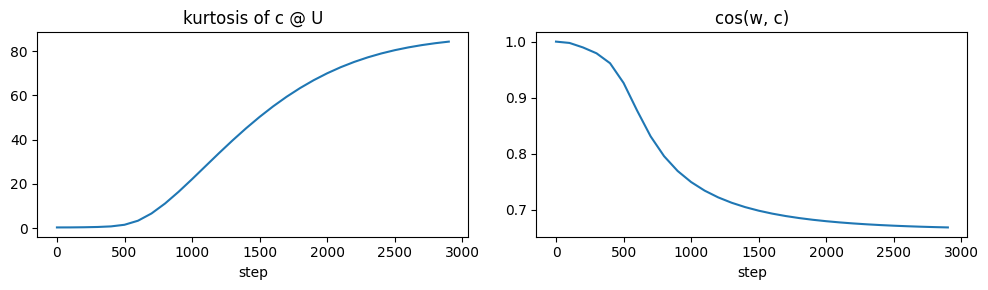

In [18]:
import matplotlib.pyplot as plt

steps, kurts, coss = zip(*history)
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(steps, kurts)
ax[0].set(title="kurtosis of c @ U", xlabel="step")
ax[1].plot(steps, coss)
ax[1].set(title="cos(w, c)", xlabel="step")
plt.tight_layout()

## 4. Many channels: mask and repeat

One channel captures one concept. To find the next, ROTATE **masks** the tokens that define the channel
just found: tokens whose z-score is beyond a threshold (4 for Gemma, 6 for Llama) on the channel's heavy
tail get weight `0.01` in `m`. Optimising again from the *original* neuron then lands on a different part
of the vocabulary. The neuron itself is never changed, so every channel is a rotation of `w`.

`find_channels` runs this loop with the paper's hyperparameters (and accepts a batch of neurons).


In [19]:
from rotate import PursuitConfig, find_channels

cfg = PursuitConfig(num_channels=NUM_CHANNELS, max_steps=MAX_STEPS, seed=0, **MODEL_CONFIGS[MODEL]["pursuit"])
t0 = time.time()
out = find_channels(w, U, m, cfg)
channels = out["channels"].to(DEVICE)  # (NUM_CHANNELS, d_model), in discovery order
print(f"done in {time.time() - t0:.0f}s\n")

for i, c in enumerate(channels):
    print(f"channel {i}: kurtosis {float(out['kurtosis'][i]):6.1f} | cos(w, c) "
          f"{float(torch.cosine_similarity(c, w, dim=0)):.2f} | masked {int(out['masked_tokens'][i]):4d} tokens"
          f" | {out['num_steps'][i]} steps")
    print("   ", ", ".join(top_tokens(c, k=10)), "\n")

channels:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/rotate/pursuit.py:312: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


done in 486s

channel 0: kurtosis   86.6 | cos(w, c) 0.67 | masked  439 tokens | 4000 steps
    ' until' (+39.1), ' Until' (+36.7), 'Until' (+36.6), 'until' (+36.6), ' till' (+34.1), ' UNTIL' (+32.7), 'Till' (+30.5), ' untill' (+30.3), ' Till' (+29.2), ' hasta' (+29.0) 

channel 1: kurtosis   54.4 | cos(w, c) 0.68 | masked  542 tokens | 3743 steps
    ' delay' (+34.8), ' Delay' (+33.4), ' delayed' (+33.1), ' Delayed' (+31.8), ' DELAY' (+30.9), 'delay' (+30.4), 'Delay' (+29.8), ' delays' (+29.5), 'Delayed' (+29.2), 'delayed' (+28.6) 

channel 2: kurtosis   88.0 | cos(w, c) 0.63 | masked  386 tokens | 4100 steps
    ' negative' (+36.7), ' Negative' (+35.8), 'Negative' (+35.1), 'negative' (+34.6), ' positive' (+32.9), ' Positive' (+32.5), 'Positive' (+31.6), 'positive' (+30.9), ' NEGATIVE' (+29.3), ' POSITIVE' (+28.7) 

channel 3: kurtosis    5.4 | cos(w, c) 0.82 | masked 1676 tokens | 3707 steps
    'afone' (+9.1), 'calaureate' (+9.0), 'phosa' (+8.9), 'yntaxException' (+8.8), 'batore' (+

## 5. Neuron vs. channels

Each channel's projection has a few tokens far out in one tail, while the neuron's projection is
spread over several groups. The channels are all close to the neuron but point to different parts of the vocabulary.


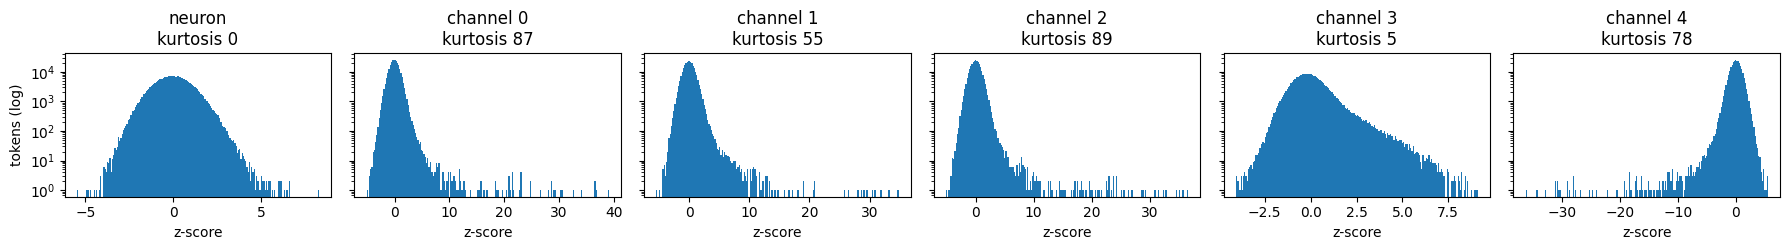

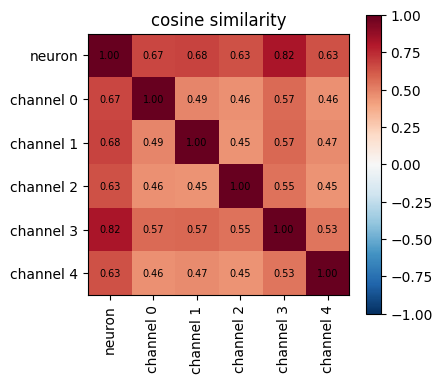

In [20]:
vecs = [("neuron", w)] + [(f"channel {i}", c) for i, c in enumerate(channels)]
fig, axes = plt.subplots(1, len(vecs), figsize=(3 * len(vecs), 2.6), sharey=True)
for ax, (name, v) in zip(axes, vecs):
    z = zscores(v).masked_select(m > 0).cpu()
    ax.hist(z.numpy(), bins=200, log=True)
    ax.set(title=f"{name}\nkurtosis {float(kurtosis(z)):.0f}", xlabel="z-score")
axes[0].set_ylabel("tokens (log)")
plt.tight_layout()

V = torch.stack([v for _, v in vecs]).float()
V = V / V.norm(dim=1, keepdim=True)
sim = (V @ V.T).cpu()
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(sim, vmin=-1, vmax=1, cmap="RdBu_r")
names = [n for n, _ in vecs]
ax.set_xticks(range(len(names)), names, rotation=90)
ax.set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("cosine similarity")
plt.colorbar(im)
plt.tight_layout()

## 6. Try your own neuron

Change `MODEL`, `LAYER`, `NEURON` or `MLP_TYPE` in the setup cell and rerun everything below it.
The neurons analysed in the paper are listed in
[`data/neuron_indices_gemma.txt`](https://github.com/AsafAvr/rotating-neurons/blob/main/data/neuron_indices_gemma.txt)
and [`data/neuron_indices_llama.txt`](https://github.com/AsafAvr/rotating-neurons/blob/main/data/neuron_indices_llama.txt).
To decompose many neurons at once, `find_channels` takes an `(N, d_model)` batch, and
[`scripts/train_channels.py`](https://github.com/AsafAvr/rotating-neurons/blob/main/scripts/train_channels.py)
runs it over whole layers. The algorithm is described in
[`docs/method.md`](https://github.com/AsafAvr/rotating-neurons/blob/main/docs/method.md).
